In [1]:
#data format library
import h5py

#numpy
import numpy as np
# import pandas as pd
import numpy.ma as ma
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams['pdf.fonttype'] = 42
# %matplotlib notebook
import sys
sys.path.append('./utils/')
import matplotlib.colors as pltcolors
import os
import copy
import partitioning_methods as cl
import coarse_graining as cgm
import operator_calculations as op_calc
import delay_embedding as embed
import stats
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import time as tt
import scipy
import glob

np.random.seed(42)

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
Fig_path = '/flash/StephensU/Gautam/Figures/Comparing_MultiScale_Dynamics/Fig_bacteria/'

In [4]:
path_to_filtered_data = '/flash/StephensU/Gautam/Multiscale_phenotypic_variation/Results/bacteria_all/'
f= h5py.File(path_to_filtered_data+'bacteria_all_data.h5','r')
print(f.keys())
bacteria_idx_all = np.array(f['MetaData/bacteria_idx_all'],dtype=int)
head_X_all = ma.asarray(f['X_all'],dtype=float)
dpsi_all = ma.array(f['dpsi_all'],dtype=float)
psi_all = ma.array(f['psi_all'],dtype=float)
msd_all = ma.array(f['msd_all'],dtype=float)
speeds_all = ma.array(f['speeds_all'],dtype=float)
lengths_all = np.array(f['MetaData/lengths_data'],dtype=int)
tbias = ma.array(f['tbias'],dtype=float)
runspeeds = ma.array(f['runspeeds'],dtype=float)
diffcoeff = ma.array(f['diffcoeff'],dtype=float)
yfp_cheb = ma.array(f['yfp_cheb'],dtype=float)
rfp_cher = ma.array(f['rfp_cher'],dtype=float)
f.close()

<KeysViewHDF5 ['MetaData', 'X_all', 'diffcoeff', 'dpsi_all', 'feats', 'meanruntime', 'msd_all', 'psi_all', 'rfp_cher', 'runspeeds', 'speeds_all', 'tbias', 'yfp_cheb']>


In [5]:
head_X_all[head_X_all==0] = ma.masked
msd_all[msd_all == 0] = ma.masked

dpsi_all[dpsi_all==0]=ma.masked
psi_all[psi_all == 0] = ma.masked
speeds_all[speeds_all==0] = ma.masked

tbias[tbias==-1] = ma.masked
diffcoeff[diffcoeff==0] = ma.masked
runspeeds[runspeeds==0] = ma.masked
rfp_cher[rfp_cher == 0] = ma.masked
yfp_cheb[yfp_cheb==0] = ma.masked

## dataset_idx = 0 for fluorescent cells, dataset_id=1 for wild types
np.where(np.diff(bacteria_idx_all)<-100)
dataset_idx = np.zeros((bacteria_idx_all.shape[0],))
dataset_idx[np.where(np.diff(bacteria_idx_all)<-100)[0][0]+1:] = 1.

(0.5861324314398327,
 5.1280351658665495,
 0.028520176456166252,
 4.510975148153805)

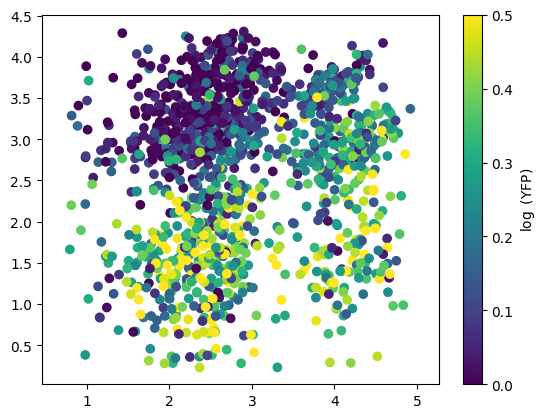

In [6]:
fig, ax = plt.subplots(1,1)
idx = np.where(dataset_idx == 0)[0]
# im = ax.scatter(diff_dists[idx,1], diff_dists[idx,2],c = np.log10(yfp_cheb.compressed()),cmap=new_cmap,s=20,norm=norm)
im = ax.scatter(np.log10(rfp_cher.compressed()),np.log10(yfp_cheb.compressed()),c = tbias[idx],cmap='viridis',vmax = 0.5,vmin=0.0,rasterized=True)
# im = ax.hexbin(np.log10(rfp_cher.compressed()),np.log10(yfp_cheb.compressed()),C = np.log10(diffcoeff)[idx],cmap='viridis',gridsize=25,vmax = 4.0,vmin=1.0)
cbar = fig.colorbar(im)
cbar.set_label(r'$\log$ (YFP)')
plt.axis('equal')
# plt.savefig(Fig_path+'/bacteria_cheR_cheB_tbias.pdf')

In [7]:
# path_to_filtered_data = '/Users/gautam.sridhar/Documents/Repos/HMD/Results/bacteria_all/'
f = h5py.File(path_to_filtered_data+'distances_combined.h5','r')
Dc_q_data = np.array(f['Dc_q_data'],dtype=float)
Dc_q_eps = np.array(f['Dc_q_eps'],dtype=float)
q_range = np.array(f['q_range'],dtype=float)
f.close()

In [14]:
eps_reg_q = np.array([np.maximum(np.percentile(Dc_q_eps[kq][np.triu_indices(Dc_q_eps.shape[1],1)],5),1e-5) for kq in range(len(q_range))])

In [15]:
Dc_q_reg_eps = []
for kq in range(len(q_range)):
    Dc_eps_copy = Dc_q_eps[kq].copy()
    Dc_eps_copy[Dc_eps_copy<eps_reg_q[kq]] = eps_reg_q[kq]
    Dc_q_reg_eps.append(Dc_eps_copy)
Dc_q_reg_eps = np.array(Dc_q_reg_eps)

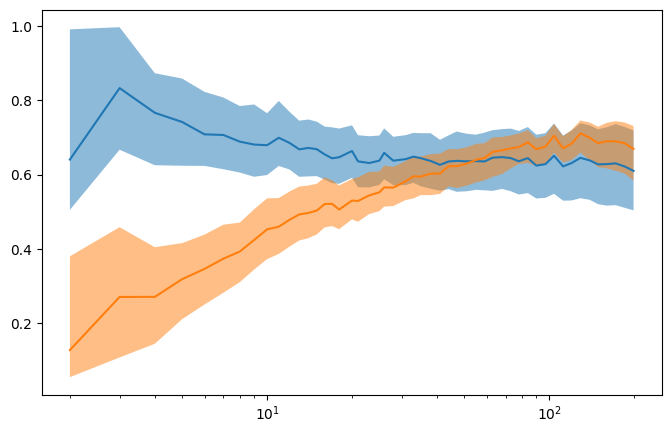

In [16]:
plt.figure(figsize=(8,5))
mean = Dc_q_data.max(axis=2).mean(axis=1)
cil = np.percentile(Dc_q_data.max(axis=2),2.5,axis=1)
ciu =  np.percentile(Dc_q_data.max(axis=2),97.5,axis=1)
plt.plot(q_range,mean,label='data')
plt.fill_between(q_range,cil,ciu,alpha=.5)

mean = Dc_q_reg_eps.max(axis=2).mean(axis=1)
cil = np.percentile(Dc_q_reg_eps.max(axis=2),2.5,axis=1)
ciu =  np.percentile(Dc_q_reg_eps.max(axis=2),97.5,axis=1)
plt.plot(q_range,mean,label='eps')
plt.fill_between(q_range,cil,ciu,alpha=.5)
# plt.axvline(11,c='k',ls='--')
# plt.axvline(3,c='k',ls='--')
# plt.axvline(12,c='k',ls='--')
# plt.axvline(91,c='k',ls='--')
plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('q')
# plt.ylabel('<D>')
# plt.xlim(2,10)
# plt.savefig(Fig_path+'/dist_v_eps.pdf')
plt.show()

In [17]:
D_ratio = Dc_q_data/(Dc_q_reg_eps)-1
for i in range(len(D_ratio)):
    np.fill_diagonal(D_ratio[i],0)
# D_ratio = Dc_q_data-Dc_q_reg_eps

D_ratio[D_ratio<0]=0
D_int = np.trapezoid(D_ratio,q_range,axis=0)
np.fill_diagonal(D_int,0)
# np.save(path_to_filtered_data + 'D_int.npy',D_int)

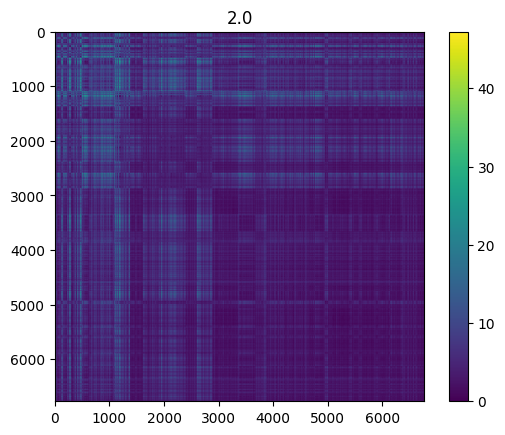

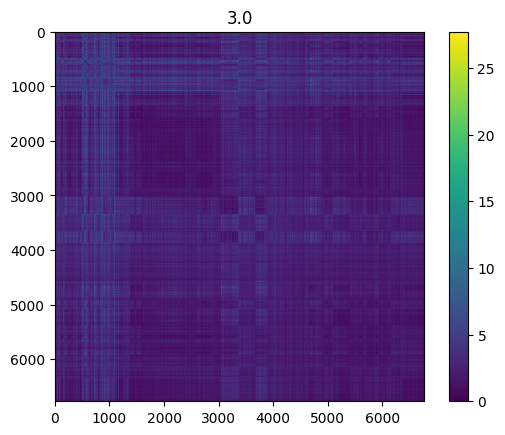

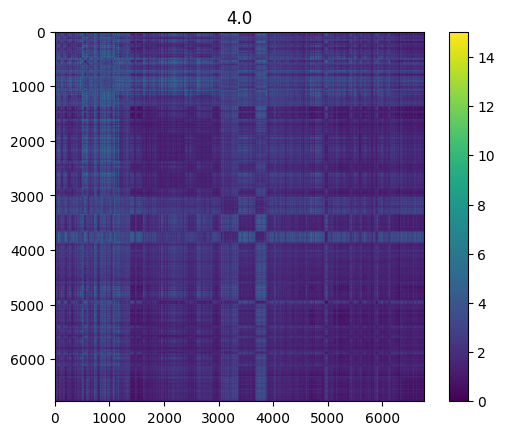

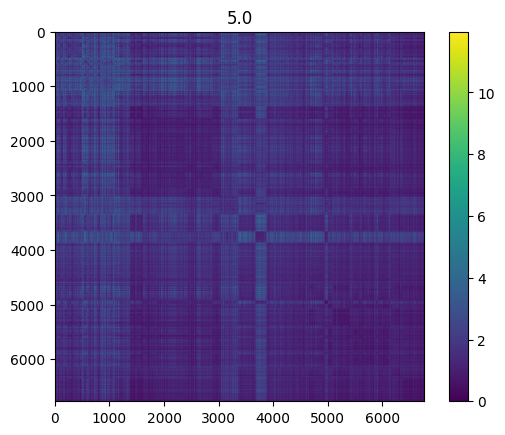

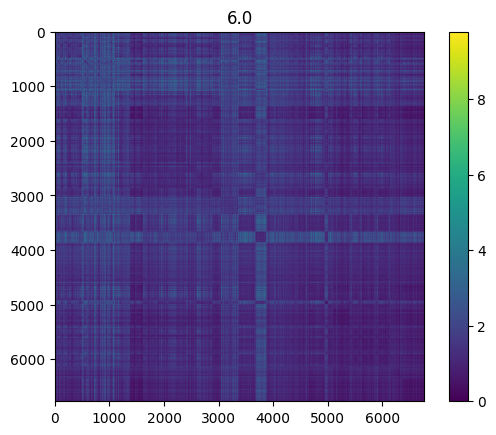

In [17]:
for i in range(5):
    plt.title(q_range[i])
    plt.imshow(D_ratio[i].data)
    plt.colorbar()
    # plt.savefig('/Users/gautam.sridhar/Documents/Post_ZENITH/Comparing_MultiScale_Dynamics/Figures/Fig_3wellpot/D_{}.pdf'.format(cgs[i]))
    plt.show()

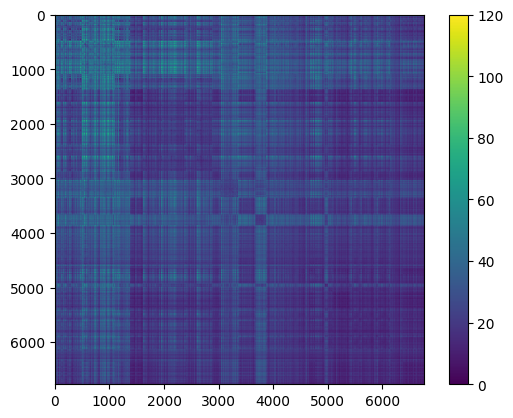

In [18]:
plt.imshow(D_int,vmax=120)
plt.colorbar()
# plt.savefig(Fig_path+'/D_int.pdf')
plt.show()

In [7]:
# np.save(path_to_filtered_data + 'D_int.npy',D_int)
D_int = np.load(path_to_filtered_data + 'D_int.npy')

In [8]:
import diffusion_maps as dmap
k=600
sorted_d = np.sort(D_int, axis=1)
M = dmap.self_tuning_diffusion_tmat(D_int,sorted_d,k,1)

In [9]:
from scipy.sparse.linalg import eigs
M = op_calc.get_reversible_transition_matrix(M)
diff_eig, diff_ev = eigs(M, k=10)
diff_inv_mes = op_calc.stationary_distribution(M)
diff_eigvecs = diff_ev / np.sqrt((diff_ev**2 * diff_inv_mes[:, None]).sum(axis=0))

sorted_indices = np.argsort(diff_eig.real)[::-1]
diff_eig = diff_eig[sorted_indices].real
diff_eigvecs = diff_eigvecs[:,sorted_indices].real
diff_dists = diff_eig*(diff_eigvecs)

# plt.axhline(ma.mean(max_eigs),c='k')
# cil = np.nanpercentile(max_eigs,2.5)
# ciu = np.nanpercentile(max_eigs,97.5)
# plt.axhspan(cil,ciu,color='k',alpha=.3)

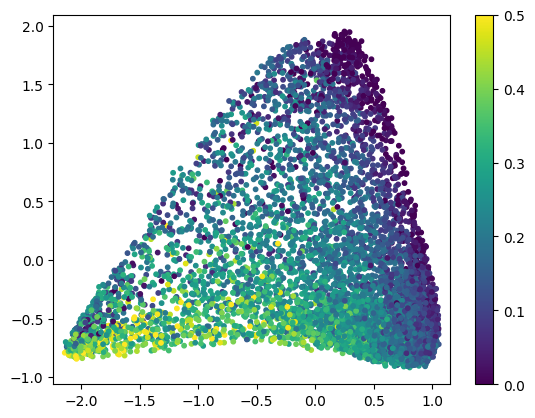

In [11]:
# fig, ax = plt.subplots(1,1,figsize=(7,7))
im = plt.scatter(-1*diff_dists[:,1], -1*diff_dists[:,2],c = tbias,cmap='viridis',s=10,vmax = 0.5,vmin=0.0,rasterized=True)
cbar = plt.colorbar(im)
# cbar.set_label(r'$\log$(Diff Coeff)')
plt.axis('equal')
plt.savefig(Fig_path+'/bacteria_diffmap_tbias.pdf')

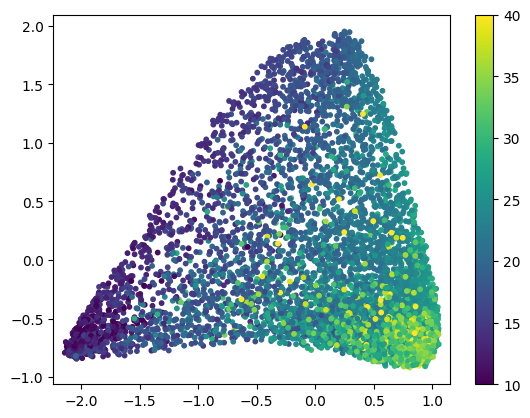

In [12]:
# fig, ax = plt.subplots(1,1,figsize=(7,7))
im = plt.scatter(-1*diff_dists[:,1], -1*diff_dists[:,2],c = runspeeds,cmap='viridis',s=10,vmin=10,vmax=40,rasterized=True)
cbar = plt.colorbar(im)
# cbar.set_label(r'$\log$(Diff Coeff)')
plt.axis('equal')
plt.savefig(Fig_path+'/bacteria_diffmap_runspeed.pdf')

In [13]:
import matplotlib.colors as colors

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap


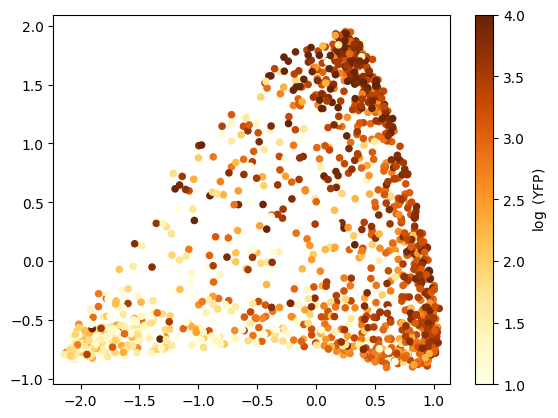

In [14]:
fig, ax = plt.subplots(1,1)
import matplotlib as mpl
idx = np.where(dataset_idx == 0)[0]
cmap = plt.get_cmap('YlOrBr')
new_cmap = truncate_colormap(cmap, 0.0, 1.0,n=len(idx))
norm = mpl.colors.Normalize(vmin=1, vmax=4)
im = ax.scatter(-1*diff_dists[idx,1], -1*diff_dists[idx,2],c = np.log10(yfp_cheb.compressed()),cmap=new_cmap,s=20,norm=norm,rasterized=True)
# im = ax.hexbin(diff_dists[idx,1], diff_dists[idx,2],C = np.log10(yfp_cheb.compressed()),cmap=new_cmap,norm=norm,gridsize=50)
cbar = fig.colorbar(im)
cbar.set_label(r'$\log$ (YFP)')
plt.axis('equal')
# plt.ylim(-0.005,0.005)
plt.savefig(Fig_path+'/bacteria_diffmap_yfp.pdf')

[   0    1    2 ... 1371 1372 1373]


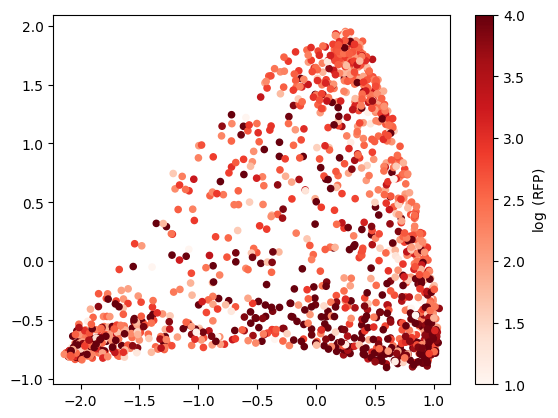

In [16]:
fig, ax = plt.subplots(1,1)
idx = np.where(dataset_idx == 0)[0]
cmap = plt.get_cmap('Reds')
new_cmap = truncate_colormap(cmap, 0.0, 1.0,n=len(idx))
norm = mpl.colors.Normalize(vmin=1, vmax=4)
print(idx)
im = ax.scatter(-1*diff_dists[idx,1], -1*diff_dists[idx,2],c = np.log10(rfp_cher.compressed()),s=20,cmap=new_cmap,vmin=1.0,vmax=4.0,rasterized=True)
# im = ax.hexbin(diff_dists[idx,1], diff_dists[idx,2],C = np.log10(rfp_cher.compressed()),cmap='Reds',gridsize=15,vmin=1.0,vmax = 5.0)

cbar = fig.colorbar(im)
cbar.set_label(r'$\log$ (RFP)')
plt.axis('equal')
# plt.ylim(-0.005,0.005)
plt.savefig(Fig_path+'/bacteria_diffmap_rfp.pdf')

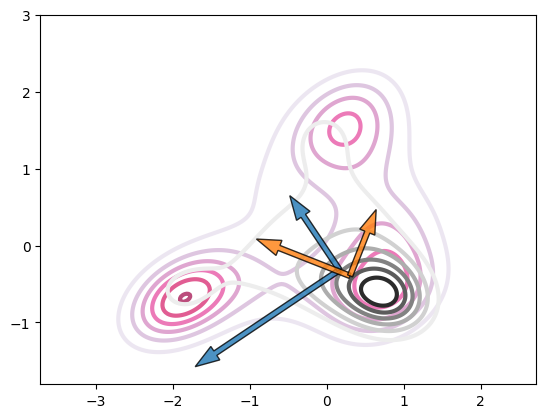

In [34]:
from scipy.stats import gaussian_kde
cmaps = ['PuRd','Greys']
fig, ax = plt.subplots(1,1)
for i in [0,1]:
    idx = np.where(dataset_idx == i)[0]
    values = -1*diff_dists[idx,1:3].T
    kernel = gaussian_kde(values,bw_method=0.4)
    X,Y = np.meshgrid(np.linspace(-3,2,200),np.linspace(-1.5,3,200))
    positions = np.vstack([X.ravel(), Y.ravel()])
    img = np.reshape(kernel(positions).T, X.shape)
    if i == 0:
        plt.contour(X,Y, img, cmap=cmaps[int(i)], linewidths=3,alpha=0.7)
    else:
        plt.contour(X,Y, img, cmap=cmaps[int(i)], linewidths=3)
    
    # img = stats.density_plot(diff_dists[idx,1], diff_dists[idx,2],[-0.04,0.02],[-0.02,0.03],70,70,smooth=True, border=3)
    # X,Y = np.meshgrid(np.linspace(-0.04,0.02,76),np.linspace(-0.02,0.03,76))
    # plt.contour(X,Y, img, cmap=cmaps[int(i)], linewidths=3)

    X = diff_dists[idx,1:3]
    X = X - np.mean(X,axis=0)
    cov = np.cov(X.T)
    e1, ev2 = np.linalg.eig(cov)
    ms = np.median(-1*diff_dists[idx,1:3],axis=0)
    plt.arrow(ms[0],ms[1], -1*1.5*e1[0]*ev2[0,0], -1*1.5*e1[0]*ev2[1,0], width = 0.07, alpha=0.8, ec='k',zorder=10,color = 'C{}'.format(i))
    plt.arrow(ms[0],ms[1], 1.5*e1[1]*ev2[0,1], 1.5*e1[1]*ev2[1,1], width = 0.07, alpha=0.8, ec='k',zorder=10,color = 'C{}'.format(i))
    
    # plt.colorbar()
plt.axis('equal')
plt.savefig(Fig_path+'dataset_densities.pdf')
plt.show()